In [72]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import seaborn as sns

from alumni_data_processing import load_alumni_json, embed_texts

sns.set_theme()

In [57]:
sample_alumni_df = pd.read_csv("sample_alumni_clustering_data.csv")
actual_alumni_df = load_alumni_json("real_alumni_data.json")

In [78]:
def extract_clustering_features(alumni_df):
    alumni_df["postgrad_concat"] = alumni_df["post_grad_summary_string"] + ". Skills: " + alumni_df["post_grad_skills_string"]
    alumni_df["career_concat"] = alumni_df["career_trajectory_string"] + " Skills: " + alumni_df["long_term_skills_string"]

    postgrad_embeddings = embed_texts(alumni_df["post_grad_summary_string"])
    career_embeddings = embed_texts(alumni_df["career_trajectory_string"])

    # Optionally standardize (sometimes helps KMeans performance)
    scaler = StandardScaler()
    X_postgrad = scaler.fit_transform(postgrad_embeddings)
    X_career = scaler.fit_transform(career_embeddings)

    return X_postgrad, X_career

def cluster_alumni_kmeans(alumni_df, k_postgrad=4, k_career=4):
    print("Extracting clustering features...")
    X_postgrad, X_career = extract_clustering_features(alumni_df)

    # KMeans clustering
    print("Clustering with KMeans...")
    postgrad_kmeans = KMeans(n_clusters=k_postgrad, random_state=42)
    career_kmeans = KMeans(n_clusters=k_career, random_state=42)

    alumni_df["postgrad_cluster"] = postgrad_kmeans.fit_predict(X_postgrad)
    alumni_df["career_cluster"] = career_kmeans.fit_predict(X_career)

    # Visualization
    print("Reducing postgrad dims...")
    postgrad_2d = umap.UMAP(random_state=42).fit_transform(X_postgrad)
    plt.scatter(postgrad_2d[:, 0], postgrad_2d[:, 1], c=alumni_df["postgrad_cluster"], cmap="Spectral")
    plt.title("Post-grad Clusters via UMAP + KMeans")
    plt.show()

    print("Reducing career dims...")
    career_2d = umap.UMAP(random_state=42).fit_transform(X_career)
    plt.scatter(career_2d[:, 0], career_2d[:, 1], c=alumni_df["career_cluster"], cmap="Spectral")
    plt.title("Career Clusters via UMAP + KMeans")
    plt.show()

    return alumni_df

Extracting clustering features...
Clustering with KMeans...
Reducing postgrad dims...


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


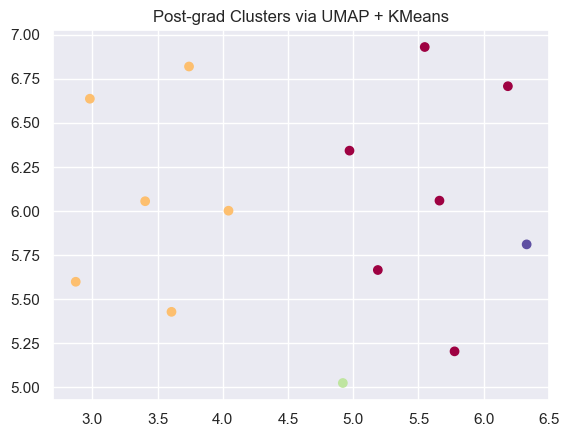

Reducing career dims...


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


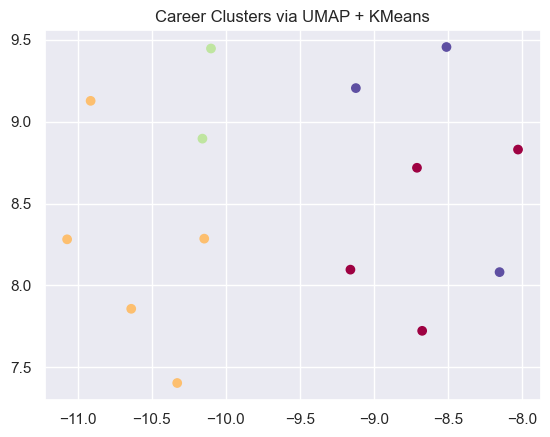

In [79]:
actual_alumni_df = cluster_alumni_kmeans(actual_alumni_df)

In [81]:
for cluster in actual_alumni_df['postgrad_cluster'].unique():
    print(f"Cluster {cluster}:")
    print(actual_alumni_df[actual_alumni_df['postgrad_cluster'] == cluster][['name','post_grad_summary_string']].values)
    print("\n")

Cluster 2:
[['Thomas Brown'
  'Joined the U.S. Department of Justice as a Paralegal Specialist in the Civil Rights Division.']]


Cluster 1:
[['Margot Putnam'
  "Completed a Master's in International Relations at Johns Hopkins SAIS and worked on monetary policy at the South African Reserve Bank."]
 ['Rahul Batlanki'
  'Began career as a Real Estate Investment Banking Analyst at Goldman Sachs.']
 ['Samantha Yao'
  'Joined Goldman Sachs as an Investment Banking Analyst covering healthcare clients.']
 ['Kendall Weingart'
  'Joined Goldman Sachs as an analyst on the Global Banking and Markets team.']
 ['Jason Acosta'
  'Began full-time as an analyst in Global Banking and Markets at Goldman Sachs.']
 ['Nicholas Zane'
  'Started full-time as an investment banking analyst at Goldman Sachs in the Industrials group.']]


Cluster 0:
[['Matt Gardner'
  'Worked at Northrop Grumman as an Electronics Engineer, then joined Formlabs as an Electrical Engineer specializing in analog circuit design.']
 [

In [82]:
for cluster in actual_alumni_df['career_cluster'].unique():
    print(f"Cluster {cluster}:")
    print(actual_alumni_df[actual_alumni_df['career_cluster'] == cluster][['name','career_trajectory_string']].values)
    print("\n")

Cluster 2:
[['Thomas Brown'
  'Public sector legal professional with a focus on civil rights and journalism.']
 ['Margot Putnam'
  'International policy expert with experience across diplomacy, finance, and development.']]


Cluster 0:
[['Matt Gardner'
  'Experienced hardware engineer pursuing advanced technical and business leadership at MIT.']
 ['Peter Desantis'
  'Long-time Amazon and AWS executive leading global cloud and infrastructure platforms.']
 ['Nour Hayek'
  'Applied hardware engineer building scalable electronics at Amazon.']
 ['Gonzalo Villalba'
  'Software engineer at Amazon focused on backend systems and infrastructure.']]


Cluster 3:
[['Benedict Tedjokusumo'
  'Established Google software engineer with full-stack experience in search and enterprise platforms.']
 ['Ravin Anderson'
  'Emerging XR-focused software engineer with experience across industry and teaching.']
 ['Sherrina Hwang'
  'Systems-focused engineer now bridging external developer integrations at Google.

In [73]:
# Optimal number of clusters
def find_optimal_k(X, k_range=range(2, 10)):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels, metric='cosine')  # 'cosine' works well for embeddings
        print(f"k={k}, silhouette_score={score:.3f}")
        scores.append(score)

    # Plot to visualize
    plt.plot(k_range, scores, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.title("Optimal k based on Silhouette Score")
    plt.show()

    # Return best k
    best_k = k_range[scores.index(max(scores))]
    return best_k


k=2, silhouette_score=0.323
k=3, silhouette_score=0.242
k=4, silhouette_score=0.179
k=5, silhouette_score=0.193
k=6, silhouette_score=0.225
k=7, silhouette_score=0.265
k=8, silhouette_score=0.237
k=9, silhouette_score=0.174


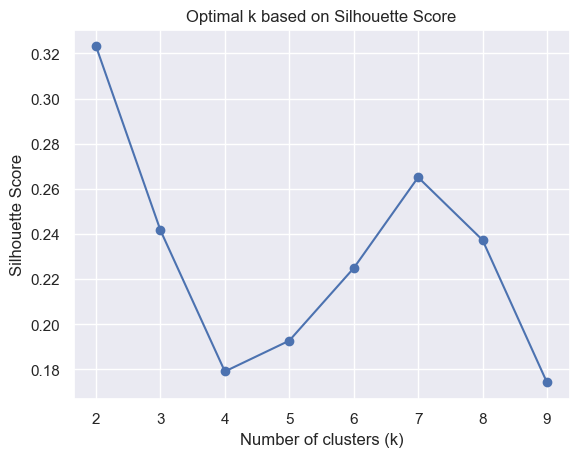

k=2, silhouette_score=0.207
k=3, silhouette_score=0.180
k=4, silhouette_score=0.165
k=5, silhouette_score=0.132
k=6, silhouette_score=0.106
k=7, silhouette_score=0.111
k=8, silhouette_score=0.119
k=9, silhouette_score=0.133


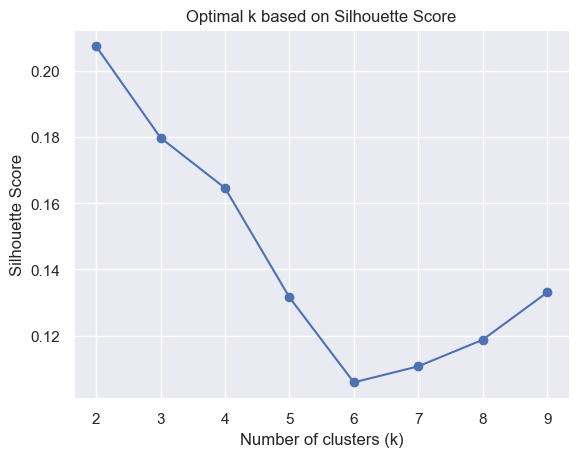

Extracting clustering features...
Clustering with KMeans...
Reducing postgrad dims...


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


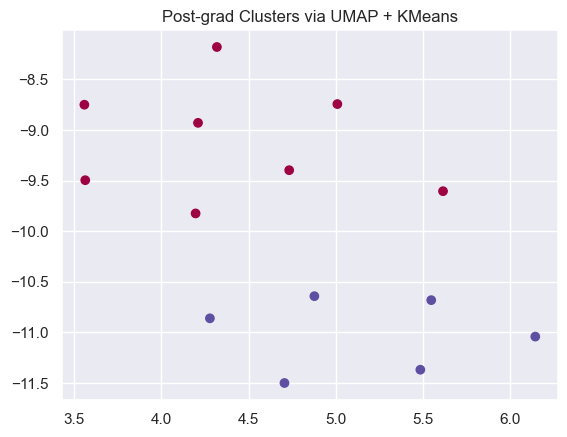

Reducing career dims...


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


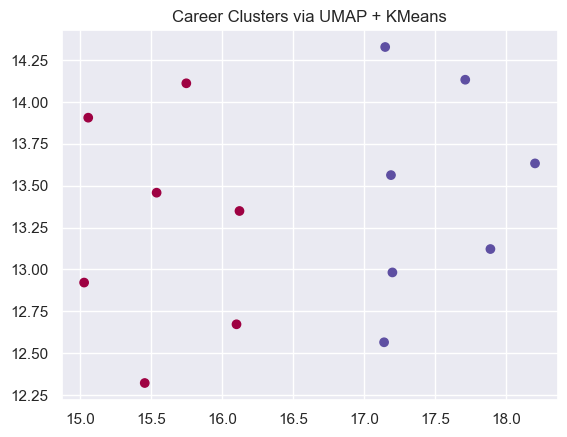

In [74]:
X_postgrad, X_career = extract_clustering_features(actual_alumni_df)

optimal_k_postgrad = find_optimal_k(X_postgrad, k_range=range(2, 10))
optimal_k_career = find_optimal_k(X_career, k_range=range(2, 10))

alumni_df = cluster_alumni_kmeans(actual_alumni_df, k_postgrad=optimal_k_postgrad, k_career=optimal_k_career)


In [86]:
from openai import OpenAI
import os

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def embed_text(text):
     
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )

    return response.data[0].embedding



In [95]:
# sentencetransformer embeddings
from sentence_transformers import SentenceTransformer

# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")

def embed_text_st(text):
    return model.encode(text)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [126]:
sample_role_data = pd.read_csv('sample_post_grad_data.csv')
# Create embeddings for sample role data for visualization

# embeddings = [embed_text(role) for role in sample_role_data['post_grad_summary_string'].values]
# embeddings_st = embed_text_st(sample_role_data['post_grad_summary_string'].values)

In [165]:
post_grad_roles = [
    "Software Engineer at Google working on Cloud Storage systems",
    "Investment Banking Analyst at Morgan Stanley in the Technology group",
    "Associate Product Manager at Spotify focused on creator tools",
    "Paralegal Specialist at the U.S. Department of Justice, Civil Rights Division",
    "PhD Student in Artificial Intelligence at Carnegie Mellon University",
    "Venture Fellow at Andreessen Horowitz, focused on digital health",
    "Research Assistant at the Federal Reserve Bank of New York",
    "Policy Analyst at the Brookings Institution specializing in urban economics",
    "UX Designer at Airbnb on the Accessibility team",
    "Data Scientist at Pfizer working in clinical trial optimization",
    "JD Candidate at Yale Law School",
    "Software Engineer at Palantir building tools for defense analytics",
    "Quantitative Research Analyst at Citadel Securities",
    "Bioinformatics Research Assistant at the Broad Institute",
    "Global Health Fellow at the World Health Organization",
    "Infrastructure Analyst at BlackRock, focused on sustainable energy",
    "Operations Associate at Stripe in the Risk & Identity team",
    "MBA Candidate at MIT Sloan School of Management",
    "Cloud Solutions Engineer at Amazon Web Services (AWS)",
    "Clinical Research Coordinator at Dana-Farber Cancer Institute",
    "Marketing Analyst at Meta for Instagram Reels",
    "Foreign Service Officer at the U.S. Department of State",
    "Co-founder of an early-stage edtech startup focused on test prep in Sub-Saharan Africa",
    "Associate Consultant at Bain & Company with a focus on healthcare clients",
    "Environmental Policy Fellow at NRDC (Natural Resources Defense Council)",
    "Software Engineer at Duolingo on the monetization team",
    "AI Policy Researcher at the Center for Security and Emerging Technology (CSET)",
    "Investment Associate at KKR in the Infrastructure group",
    "Graduate Research Assistant at Stanford Vision & Learning Lab (SVL)",
    "Backend Engineer at Dropbox working on document synchronization",
    "Journalist at ProPublica investigating state-level corruption",
    "Technical Program Manager at NVIDIA for Autonomous Vehicles",
    "Co-founder of a climate fintech startup focused on carbon credits",
    "Product Designer at Figma for cross-platform collaboration features",
    "Embedded Systems Engineer at Tesla working on battery management systems",
    "Strategy Analyst at Google on the YouTube Music team",
    "Legislative Aide in the U.S. Senate focused on immigration reform",
    "AI Resident at FAIR (Facebook AI Research)",
    "Assistant Curator at the Museum of Modern Art, New York",
    "Solutions Engineer at Snowflake serving enterprise data clients"
]


In [166]:
embeddings = [embed_text(role_summary) for role_summary in post_grad_roles]

In [170]:
from sklearn.metrics.pairwise import cosine_similarity

Clustering with KMeans...
Reducing postgrad dims...


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


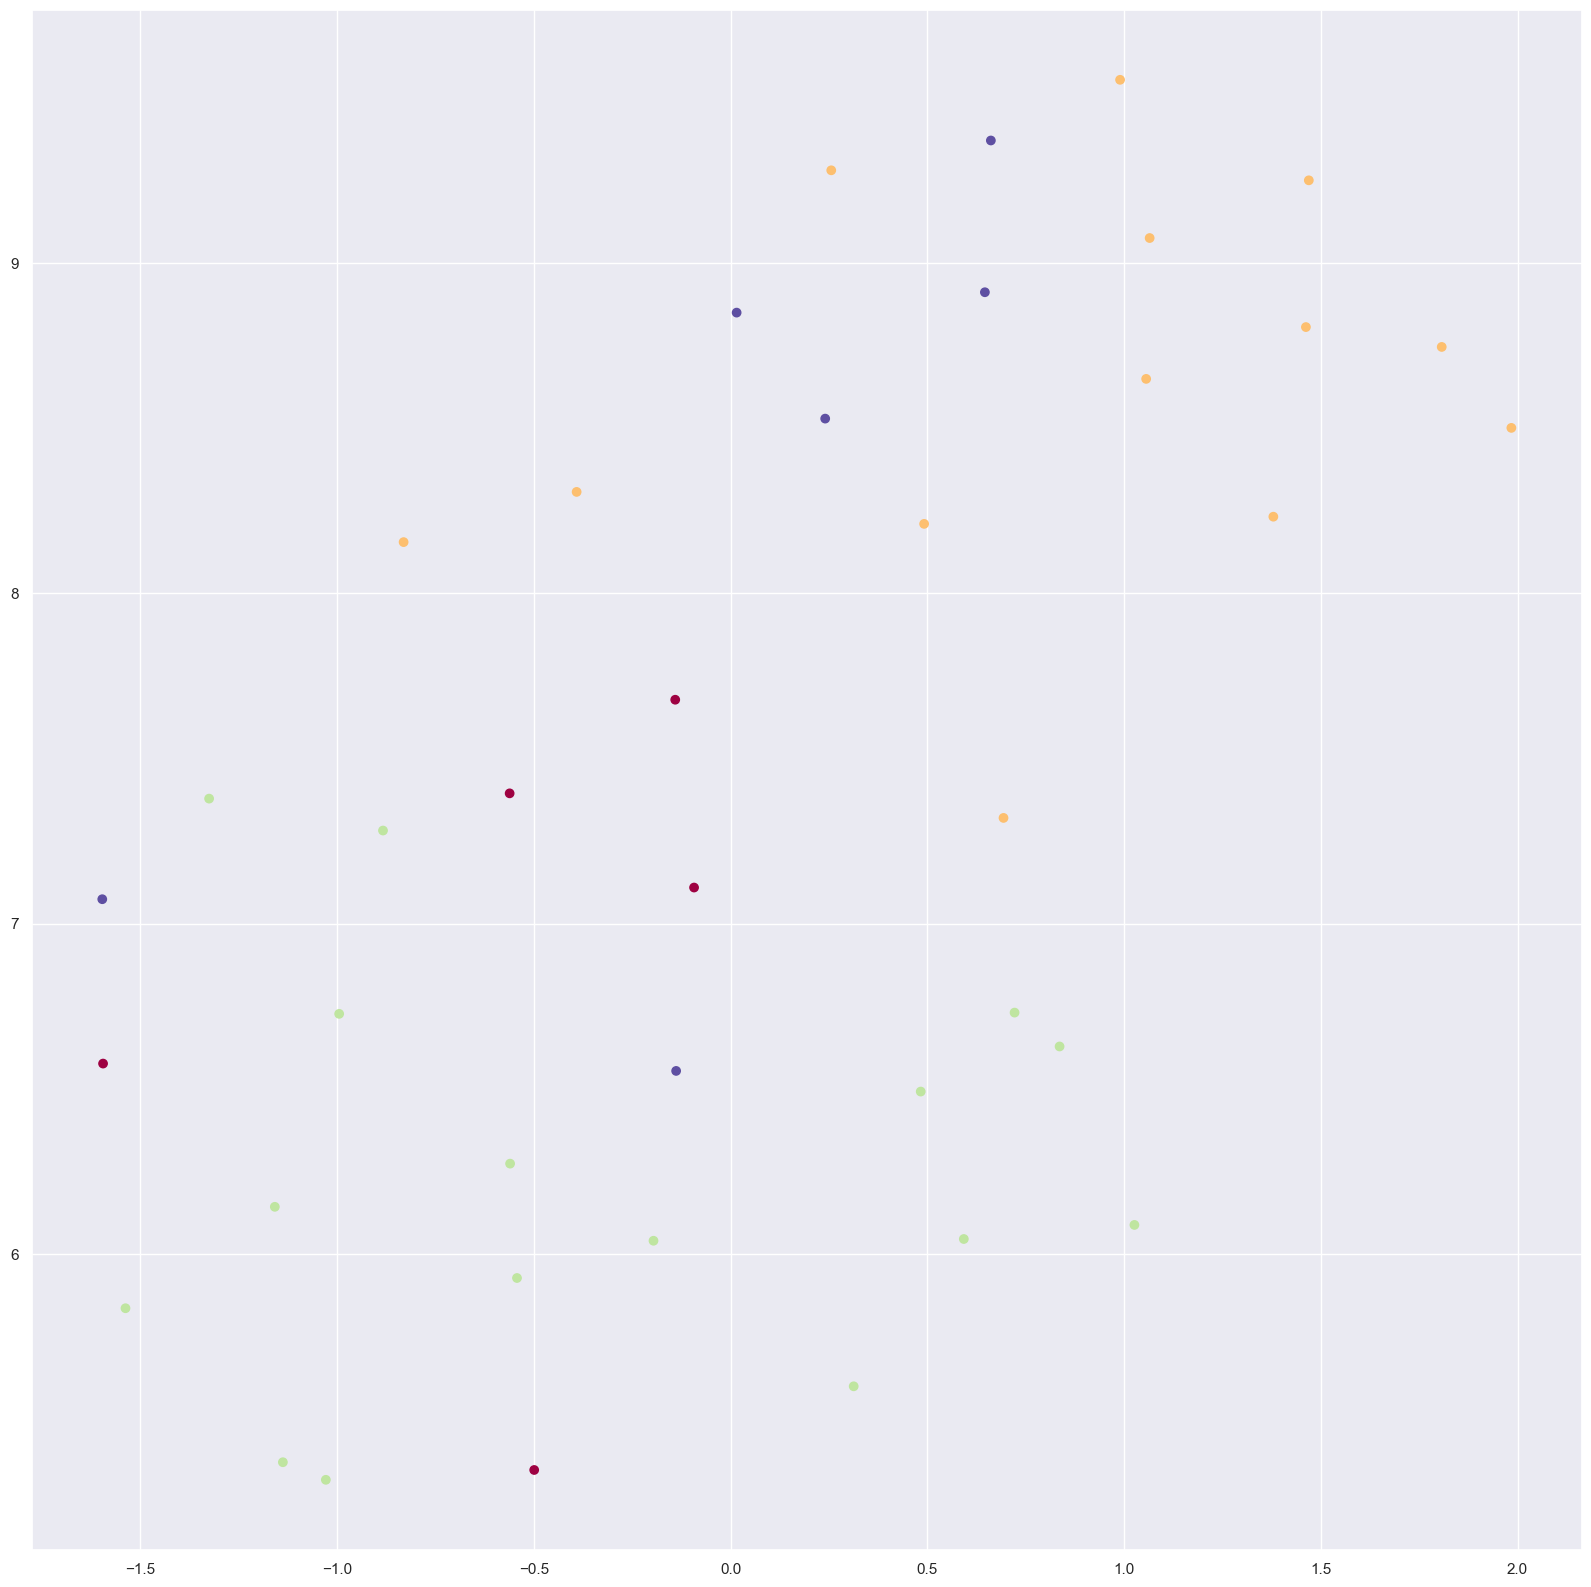

In [168]:
print("Clustering with KMeans...")
post_grad_kmeans = KMeans(n_clusters=4, random_state=42)

postgrad_clusters = post_grad_kmeans.fit_predict(embeddings)

# Visualization
print("Reducing postgrad dims...")
postgrad_2d = umap.UMAP(random_state=42).fit_transform(embeddings)
plt.figure(figsize=(20, 20))
plt.scatter(postgrad_2d[:, 0], postgrad_2d[:, 1], c=postgrad_clusters, cmap="Spectral")

# print the labels
# for i, label in enumerate(sample_role_data['role_category'].values):
#     plt.text(postgrad_2d[i, 0]+0.2, postgrad_2d[i, 1]+0.2, label, fontsize=9)
# plt.title("Post-grad Clusters via UMAP + KMeans")
# plt.show()

In [163]:
sample_student_goals = ['Software Developer at Amazon working on Artificial General Intelligence',
                        'Pursue a PhD in Computer Science',
                        'Build an edtech startup to help students learn in a personalized way',
                        'Software Developer at Google working on AI',
                        'Law school at Harvard']

student_embeddings = {student_goal: embed_text(student_goal) for student_goal in sample_student_goals}

for student_goal, embedding in student_embeddings.items():
    print(f'For student goal: {student_goal}')
    sim = cosine_similarity([embedding], post_grad_kmeans.cluster_centers_)
    top_cluster_idx = np.argmax(sim)

    print(f"The sample student's post-grad role belongs to cluster {top_cluster_idx}")
    print(sample_role_data[sample_role_data['postgrad_cluster'] == top_cluster_idx]['post_grad_summary_string'].values)
    print("----------------------------------\n")


For student goal: Software Developer at Amazon working on Artificial General Intelligence
The sample student's post-grad role belongs to cluster 2
['Software Developer at Amazon' 'Software Developer at Google'
 'Software Developer at Meta' 'Backend Engineer at Stripe'
 'Software Engineer at Netflix' 'Frontend Engineer at Airbnb'
 'SWE at Microsoft' 'Software Developer at LinkedIn'
 'Full Stack Engineer at DoorDash' 'ML Infrastructure Engineer at Apple'
 'Platform Engineer at Uber' 'Cloud Engineer at AWS'
 'DevOps Engineer at Adobe' 'Site Reliability Engineer at Dropbox'
 'iOS Engineer at Robinhood']
----------------------------------

For student goal: Pursue a PhD in Computer Science
The sample student's post-grad role belongs to cluster 0
['Postdoctoral Researcher at CMU'
 'Postdoctoral Researcher at the Broad Institute'
 'Research Scientist at DeepMind' 'Postdoc in NLP at Stanford'
 'AI Research Fellow at MIT' 'Postdoctoral Fellow at Harvard SEAS'
 'Researcher at OpenAI' 'Postdoc at

/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


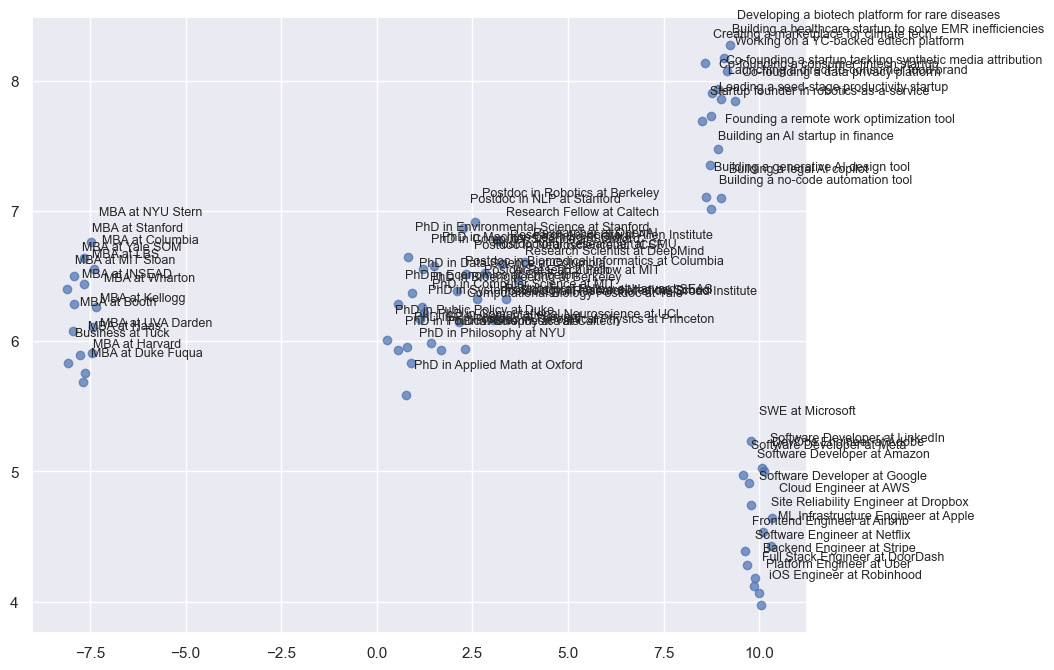

In [148]:
# vsualize embeddings for DF
umap_reducer = umap.UMAP(n_components=2, random_state=0)
embedding_2d = umap_reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.7)

for i, label in enumerate(sample_role_data['post_grad_summary_string'].values):
    plt.text(embedding_2d[i, 0]+0.2, embedding_2d[i, 1]+0.2, label, fontsize=9)


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


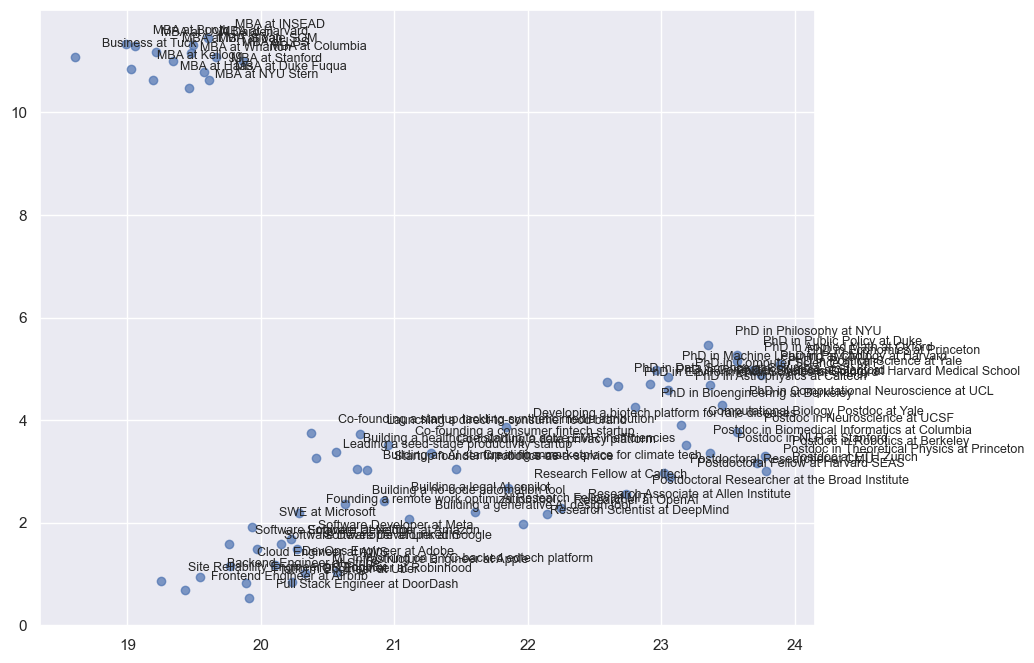

In [149]:
# vsualize embeddings for DF
umap_reducer = umap.UMAP(n_components=2, random_state=0)
embedding_2d = umap_reducer.fit_transform(embeddings_st)

plt.figure(figsize=(10, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.7)

for i, label in enumerate(sample_role_data['post_grad_summary_string'].values):
    plt.text(embedding_2d[i, 0]+0.2, embedding_2d[i, 1]+0.2, label, fontsize=9)


In [120]:
ex_role = 'Software Developer at Amazon'

# sentencetransformer embeddings
ex_role_embedding_st = embed_text_st(ex_role)
all_role_embeddings_st = embed_text_st(all_roles)

similarity_scores_st = cosine_similarity([all_role_embeddings_st[0]], all_role_embeddings_st)

# openai embeddings
ex_role_embedding = embed_text(ex_role)
all_role_embeddings = np.array([embed_text(role) for role in all_roles])

similarity_scores = cosine_similarity([all_role_embeddings[0]], all_role_embeddings)


/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/kabirmoghe/Documents/course-match/env/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


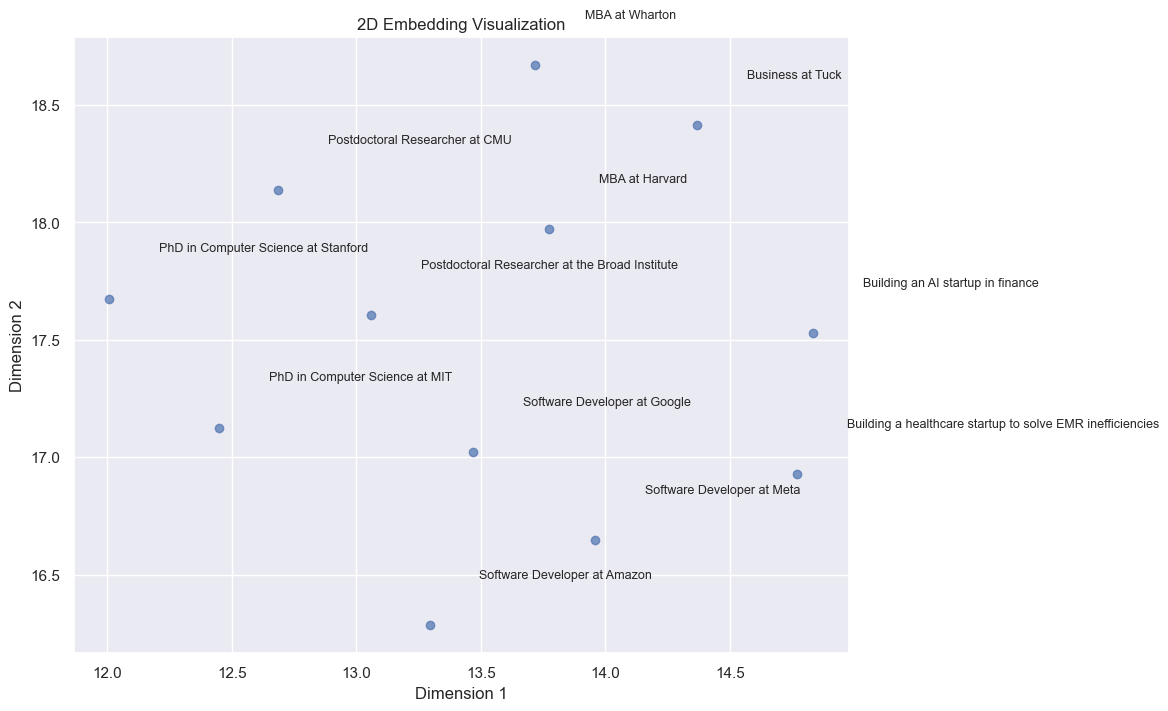

In [125]:
# Visualize the embeddings using umap
umap_reducer = umap.UMAP(n_components=2, random_state=0)
embedding_2d = umap_reducer.fit_transform(all_role_embeddings))

# Visualize with labels
plt.figure(figsize=(10, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.7)

for i, label in enumerate(all_roles):
    plt.text(embedding_2d[i, 0]+0.2, embedding_2d[i, 1]+0.2, label, fontsize=9)

plt.title("2D Embedding Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
